<a href="https://colab.research.google.com/github/Vyahriti/Fruit-Game-33/blob/main/fashion_mnist_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modern Deep Learning:
# Classify Fashion-MNIST with a simple CNN in Keras

<br> By Margaret Maynard-Reid, 4/24/2018

![alt text](https://github.com/margaretmz/deep-learning/blob/master/images/modern%20dl_fash-mnist_keras.png?raw=1)

## Why Jupyter Notebook?


*   Interactive programming in the web browser
*   Great for visualization
*   Great for collabration
*   Popular tool for studying machine learning / deep learning




## Why Fashion-MNIST?


*   MNIST is too easy
*   MNIST is overused
*   MNIST can not represent modern Computer Vision tasks

Read more about the Fashion-MINST dataset in this paper [here](https://arxiv.org/abs/1708.07747) (**Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms**)



## Notebook Overview

<br> **Notebook location on github**: https://github.com/margaretmz/deep-learning/blob/master/fashion_mnist_keras.ipynb

This is a tutorial of how to classify **fashion_mnist** data with a simple **Convolutional Neural Network** in Keras.
Keras is now part of the core TensorFlow library, in addition to being an independent open source project.

The [fashion_mnist](https://github.com/zalandoresearch/fashion-mnist) data:
60,000 train and 10,000 test data with 10 categories. Each gray-scale image is 28x28.

<br> **Label**	**Description**
<br> 0 T-shirt/top
<br> 1 Trouser
<br> 2 Pullover
<br> 3 Dress
<br> 4 Coat
<br> 5 Sandal
<br> 6 Shirt
<br> 7 Sneaker
<br> 8 Bag
<br> 9 Ankle boot

Each gray-scale image is 28x28

>[Modern Deep Learning:](#scrollTo=r2NPAI4jZZgi)

>[Classify Fashion-MNIST with a simple CNN in Keras](#scrollTo=r2NPAI4jZZgi)

>>[Why Jupyter Notebook?](#scrollTo=18xLQCydFHqi)

>>[Why Fashion-MNIST?](#scrollTo=XLMRPLVCFwEc)

>>[Notebook Overview](#scrollTo=Ixyte299ZZgk)

>>[Download the fashion_mnist data](#scrollTo=LbCigZtNZZgl)

>>[Visualize the data](#scrollTo=tWORMSC8FDR4)

>>[Data normalization](#scrollTo=Zx-Ee6LHZZgt)

>>[Split the data into train/validation/test data sets](#scrollTo=CFlNHktHBtru)

>>[Create the model architecture](#scrollTo=HhalcO03ZZg3)

>>[Compile the model](#scrollTo=FhxJ5dinZZg8)

>>[Train the model](#scrollTo=DtOvh3YVZZg_)

>>[Load Model with the best validation accuracy](#scrollTo=e-MGLwZQy05d)

>>[Test Accuracy](#scrollTo=9RTRkan4yq5H)

>>[Visualize prediction](#scrollTo=oJv7XEk10bOv)

>>[Congragulations!](#scrollTo=8AehWdRAVKN5)



## Download the fashion_mnist data
First let's install TensorFlow version 1.8.0 and import Tensorflow. Then we download fashion-mnist which is one of the Keras datasets.

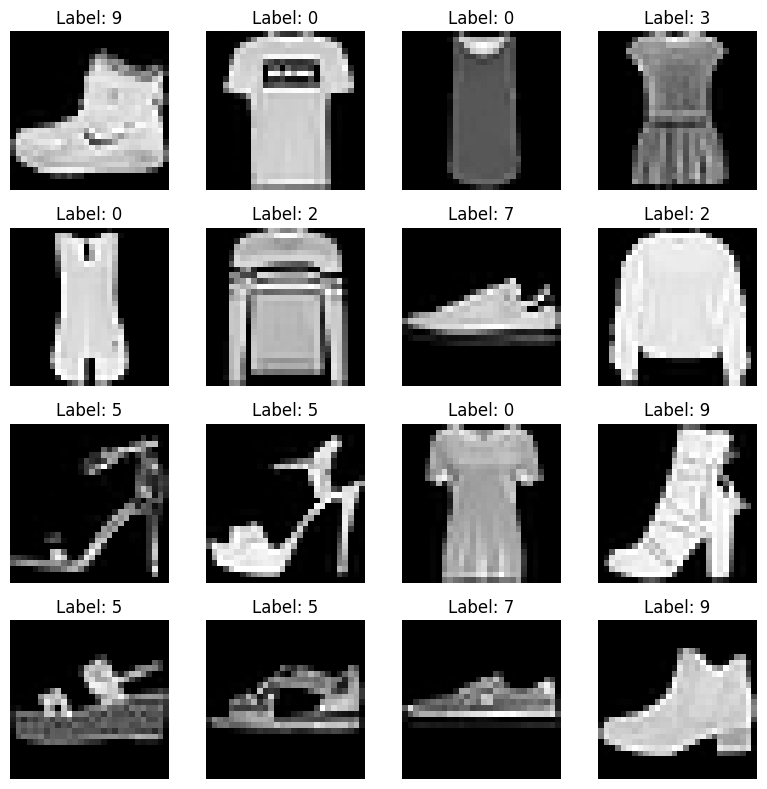

In [3]:

import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt


transform = transforms.ToTensor()
train_data = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

fig, axs = plt.subplots(4,4, figsize=(8,8))

for i in range(4):
    for j in range(4):
        image, label = train_data[i * 4 + j]  # Get image and label
        image_numpy = image.numpy().squeeze()    # Convert image tensor to numpy array
        axs[i, j].imshow(image_numpy, cmap='gray')  # Plot the image
        axs[i, j].axis('off')  # Turn off axis
        axs[i, j].set_title(f"Label: {label}")

plt.tight_layout()  # Adjust layout
plt.show()

## Visualize the data

In [4]:
from torch import nn
from torch.utils.data import DataLoader
train_data = DataLoader(train_data, batch_size=64, shuffle=True)
test_data = DataLoader(test_data, batch_size=64, shuffle=False)
for X,y in train_data:
    print(X.shape)
    print(y.shape)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [6]:
from torch import optim
class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )


    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)
def train(dataset, model, optimizer, loss_fn):
  size = len(dataset.dataset)
  model.train()
  for batch, (X,y) in enumerate(dataset):
    prediction = model(X)
    loss = loss_fn(prediction, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataset, model, loss_fn):
  size = len(dataset.dataset)
  numBatches = len(dataset)
  model.eval()
  testLoss, correct = 0, 0
  with torch.no_grad():
    for X,y in dataset:
      prediction = model(X)
      testLoss += loss_fn(prediction, y).item()
      correct += (prediction.argmax(1) == y).type(torch.float).sum().item()
  testLoss /= numBatches
  correct /= size
  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {testLoss:>8f} \n")





In [7]:
epochs = 10
for z in range(epochs):
  train(train_data, model, optimizer, loss_fn)
  test(test_data, model, loss_fn)

Test Error: 
 Accuracy: 50.2%, Avg loss: 2.154101 

Test Error: 
 Accuracy: 53.2%, Avg loss: 1.875047 

Test Error: 
 Accuracy: 59.9%, Avg loss: 1.511722 

Test Error: 
 Accuracy: 62.3%, Avg loss: 1.254016 

Test Error: 
 Accuracy: 63.6%, Avg loss: 1.093382 

Test Error: 
 Accuracy: 65.9%, Avg loss: 0.987818 

Test Error: 
 Accuracy: 67.5%, Avg loss: 0.914785 

Test Error: 
 Accuracy: 68.3%, Avg loss: 0.861296 

Test Error: 
 Accuracy: 69.4%, Avg loss: 0.821357 

Test Error: 
 Accuracy: 71.3%, Avg loss: 0.787122 



In [9]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")
model = NeuralNet()
model.load_state_dict(torch.load("model.pth", weights_only=True))

Saved PyTorch Model State to model.pth


<All keys matched successfully>

In [19]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
# Get one batch from the test_data DataLoader
data_batch = next(iter(test_data))
x, y = data_batch # Get the first image and label from the batch


with torch.no_grad():
    pred = model(x)
    predicted=pred.argmax(dim=1)
    predicted_labels = [classes[i] for i in predicted.cpu().numpy()]
    actual_labels = [classes[i] for i in y.cpu().numpy()]
    print(predicted_labels)
    print(actual_labels)


['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Coat', 'Sneaker', 'Sneaker', 'Coat', 'Sandal', 'Sneaker', 'Dress', 'Coat', 'Trouser', 'Pullover', 'Pullover', 'Bag', 'T-shirt/top', 'T-shirt/top', 'Sneaker', 'Sneaker', 'Sneaker', 'Trouser', 'Pullover', 'Coat', 'Dress', 'Ankle boot', 'Dress', 'Bag', 'Bag', 'Dress', 'Dress', 'Bag', 'T-shirt/top', 'Sneaker', 'Sneaker', 'Sneaker', 'Ankle boot', 'T-shirt/top', 'Trouser', 'Dress', 'Ankle boot', 'Coat', 'Ankle boot', 'Shirt', 'Trouser', 'Coat', 'Pullover', 'Pullover', 'Pullover', 'Sneaker', 'Shirt', 'Coat', 'Pullover', 'Bag', 'Coat', 'Bag', 'T-shirt/top', 'Sneaker', 'Sneaker', 'Bag', 'Sandal']
['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser', 'Coat', 'Shirt', 'Sandal', 'Sneaker', 'Coat', 'Sandal', 'Sneaker', 'Dress', 'Coat', 'Trouser', 'Pullover', 'Coat', 'Bag', 'T-shirt/top', 'Pullover', 'Sandal', 'Sneaker', 'Ankle boot', 'Trouser', 'Coat', 'Shirt', 'T-shirt/top', 'Ankle boot', 'Dress', 'Bag', '